In [59]:
from sklearn import preprocessing
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing

In [60]:
import pandas as pd
#Get dataset
mydata = pd.read_csv("C:/Users/Owner/IAF 603/IAF 603/kc_house_data.csv",sep = ',')

# Explanatory data analysis

In [61]:
mydata.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [62]:
mydata.tail()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287
21612,1523300157,20141015T000000,325000.0,2,0.75,1020,1076,2.0,0,0,...,7,1020,0,2008,0,98144,47.5941,-122.299,1020,1357


In [63]:
mydata.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
id,21613.0,4.580302e+09,2.876566e+09,1.000102e+06,2.123049e+09,3.904930e+09,7.308900e+09,9.900000e+09
price,21613.0,5.400881e+05,3.671272e+05,7.500000e+04,3.219500e+05,4.500000e+05,6.450000e+05,7.700000e+06
bedrooms,21613.0,3.370842e+00,9.300618e-01,0.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.300000e+01
bathrooms,21613.0,2.114757e+00,7.701632e-01,0.000000e+00,1.750000e+00,2.250000e+00,2.500000e+00,8.000000e+00
sqft_living,21613.0,2.079900e+03,9.184409e+02,2.900000e+02,1.427000e+03,1.910000e+03,2.550000e+03,1.354000e+04
sqft_lot,21613.0,1.510697e+04,4.142051e+04,5.200000e+02,5.040000e+03,7.618000e+03,1.068800e+04,1.651359e+06
floors,21613.0,1.494309e+00,5.399889e-01,1.000000e+00,1.000000e+00,1.500000e+00,2.000000e+00,3.500000e+00
waterfront,21613.0,7.541757e-03,8.651720e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
view,21613.0,2.343034e-01,7.663176e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
condition,21613.0,3.409430e+00,6.507430e-01,1.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00


# Data cleaning
#Let's reduce the dataset by dropping columns that won't be used during the analysis

In [64]:
mydata.drop(['id', 'date','sqft_living15','sqft_lot15'], axis = 1, inplace = True)

#Checking missing data before proceed to the next step

In [65]:
mydata.isna().sum()

price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
dtype: int64

In [66]:
mydata[pd.isna(mydata['waterfront'])][['waterfront', 'lat', 'long']]

,waterfront,lat,long


In [67]:
NA_Count = pd.DataFrame({'Sum of NA':mydata.isnull().sum()}).sort_values(by=['Sum of NA'],ascending=[0])
NA_Count['Percentage'] = NA_Count['Sum of NA']/mydata.shape[1]

In [68]:
sum(NA_Count['Percentage'])

0.0

# no missing value on these dataset

# Changing the data types

In [69]:
mydata[mydata['waterfront']==1.0][['waterfront', 'lat', 'long']]

,waterfront,lat,long
49,1,47.4041,-122.451
230,1,47.4497,-122.375
246,1,47.6338,-122.072
264,1,47.4683,-122.438
300,1,47.6053,-122.077
...,...,...,...
19984,1,47.6318,-122.071
20325,1,47.5283,-122.205
20767,1,47.5724,-122.104
21201,1,47.5285,-122.205


In [70]:
# we don't need because no na's values 
#mydata['waterfront'] = mydata['waterfront'].fillna(0.0)
#mydata.info()

In [71]:
mydata.view.value_counts()

view
0    19489
2      963
3      510
1      332
4      319
Name: count, dtype: int64

In [72]:
#we don't need it
#mydata = mydata.dropna(subset=['view'])

In [73]:
mydata.yr_renovated.value_counts()

yr_renovated
0       20699
2014       91
2013       37
2003       36
2005       35
        ...  
1948        1
1951        1
1959        1
1934        1
1944        1
Name: count, Length: 70, dtype: int64

In [74]:
never_renovated = mydata[mydata['yr_renovated'] == 0.0]['yr_built']
never_renovated.describe()

count    20699.000000
mean      1972.395092
std         28.855465
min       1900.000000
25%       1953.000000
50%       1977.000000
75%       1998.000000
max       2015.000000
Name: yr_built, dtype: float64

In [75]:
mydata['waterfront']=mydata['waterfront'].astype('bool')
mydata['yr_renovated'] = mydata['yr_renovated'].astype('category')

# create some new variables in our dataset.

In [76]:
mydata['basement_present'] = mydata['sqft_basement'].apply(lambda x: 1 if x > 0 else 0) # Indicate whether there is a basement or not
mydata['renovated'] = mydata['yr_renovated'].apply(lambda x: 1 if x > 0 else 0) # 1 if the house has been renovated

In [77]:
mydata = mydata.drop(['sqft_basement','sqft_above'],axis=1)

# Checking outliers and data distributions 

# No of bedrooms and Bathrooms

<Axes: xlabel='bathrooms', ylabel='count'>

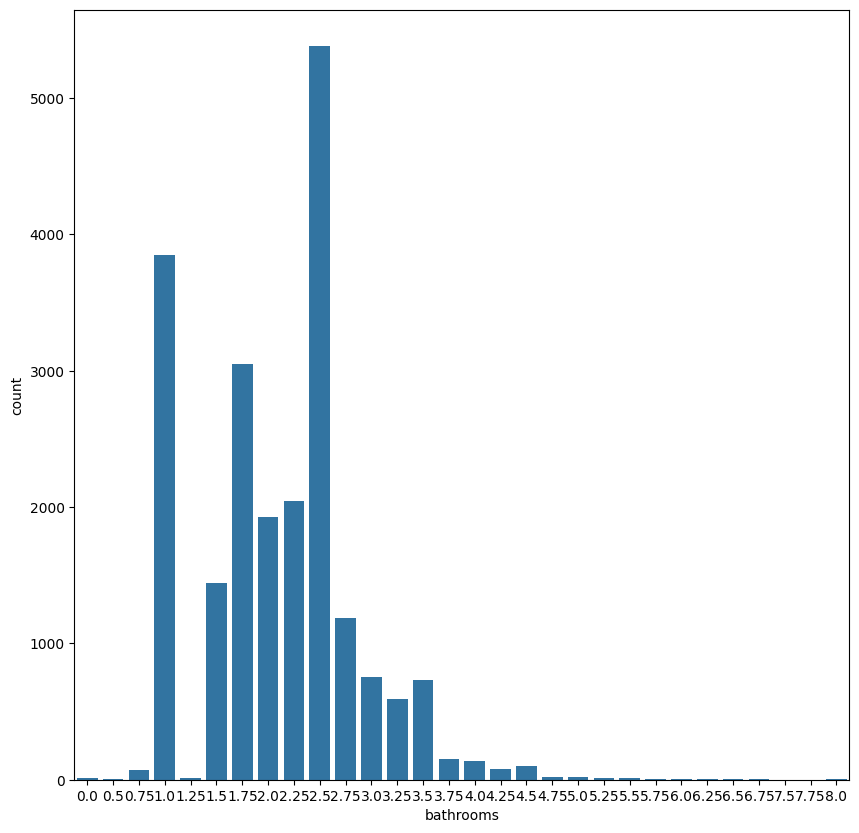

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=[10,10])
sns.countplot(x=mydata['bathrooms'], data=mydata)  # outliers present

In [79]:
# drop data with zero bedrooms and bathrooms and bedrooms outlier
mydata = mydata.drop(mydata[mydata.bedrooms == 0].index)
mydata = mydata.drop(mydata[mydata.bedrooms == 33].index)
mydata = mydata.drop(mydata[mydata.bathrooms == 0].index)

Distribution of Prices


C:\Users\Owner\AppData\Local\Temp\ipykernel_29312\1739201349.py:3: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




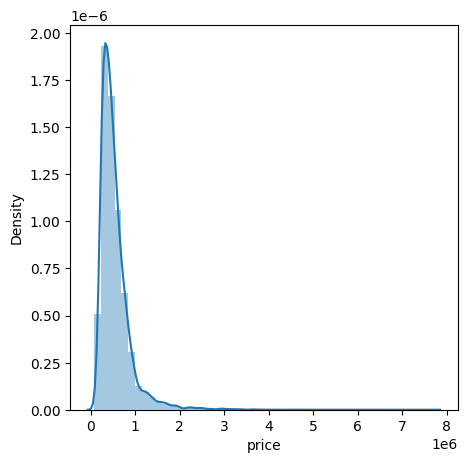

In [80]:
#Distribution of house prices
fig=plt.figure(figsize=[5,5])
sns.distplot(mydata['price'])  # outliers present
print('Distribution of Prices')

Text(0.5, 0, 'Price ($)')

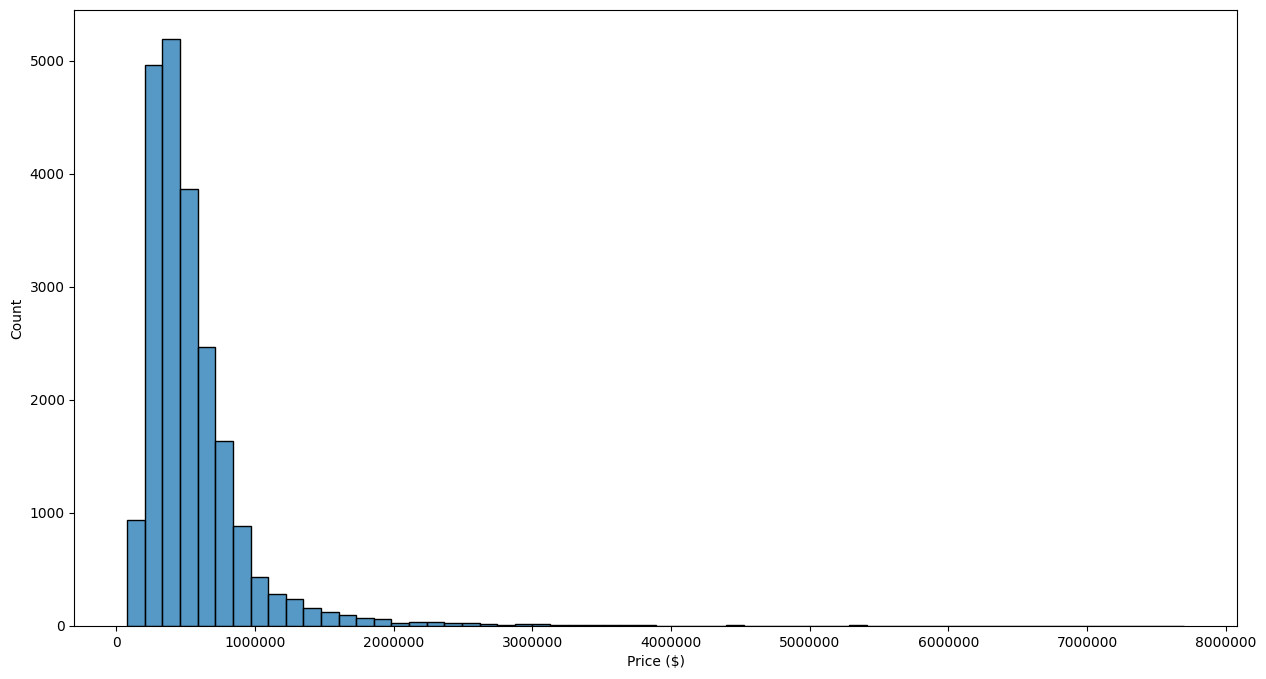

In [81]:
fig=plt.figure(figsize=[15,8])
sns.histplot(mydata['price'],bins=60)
plt.ticklabel_format(style='plain')
plt.xlabel("Price ($)")

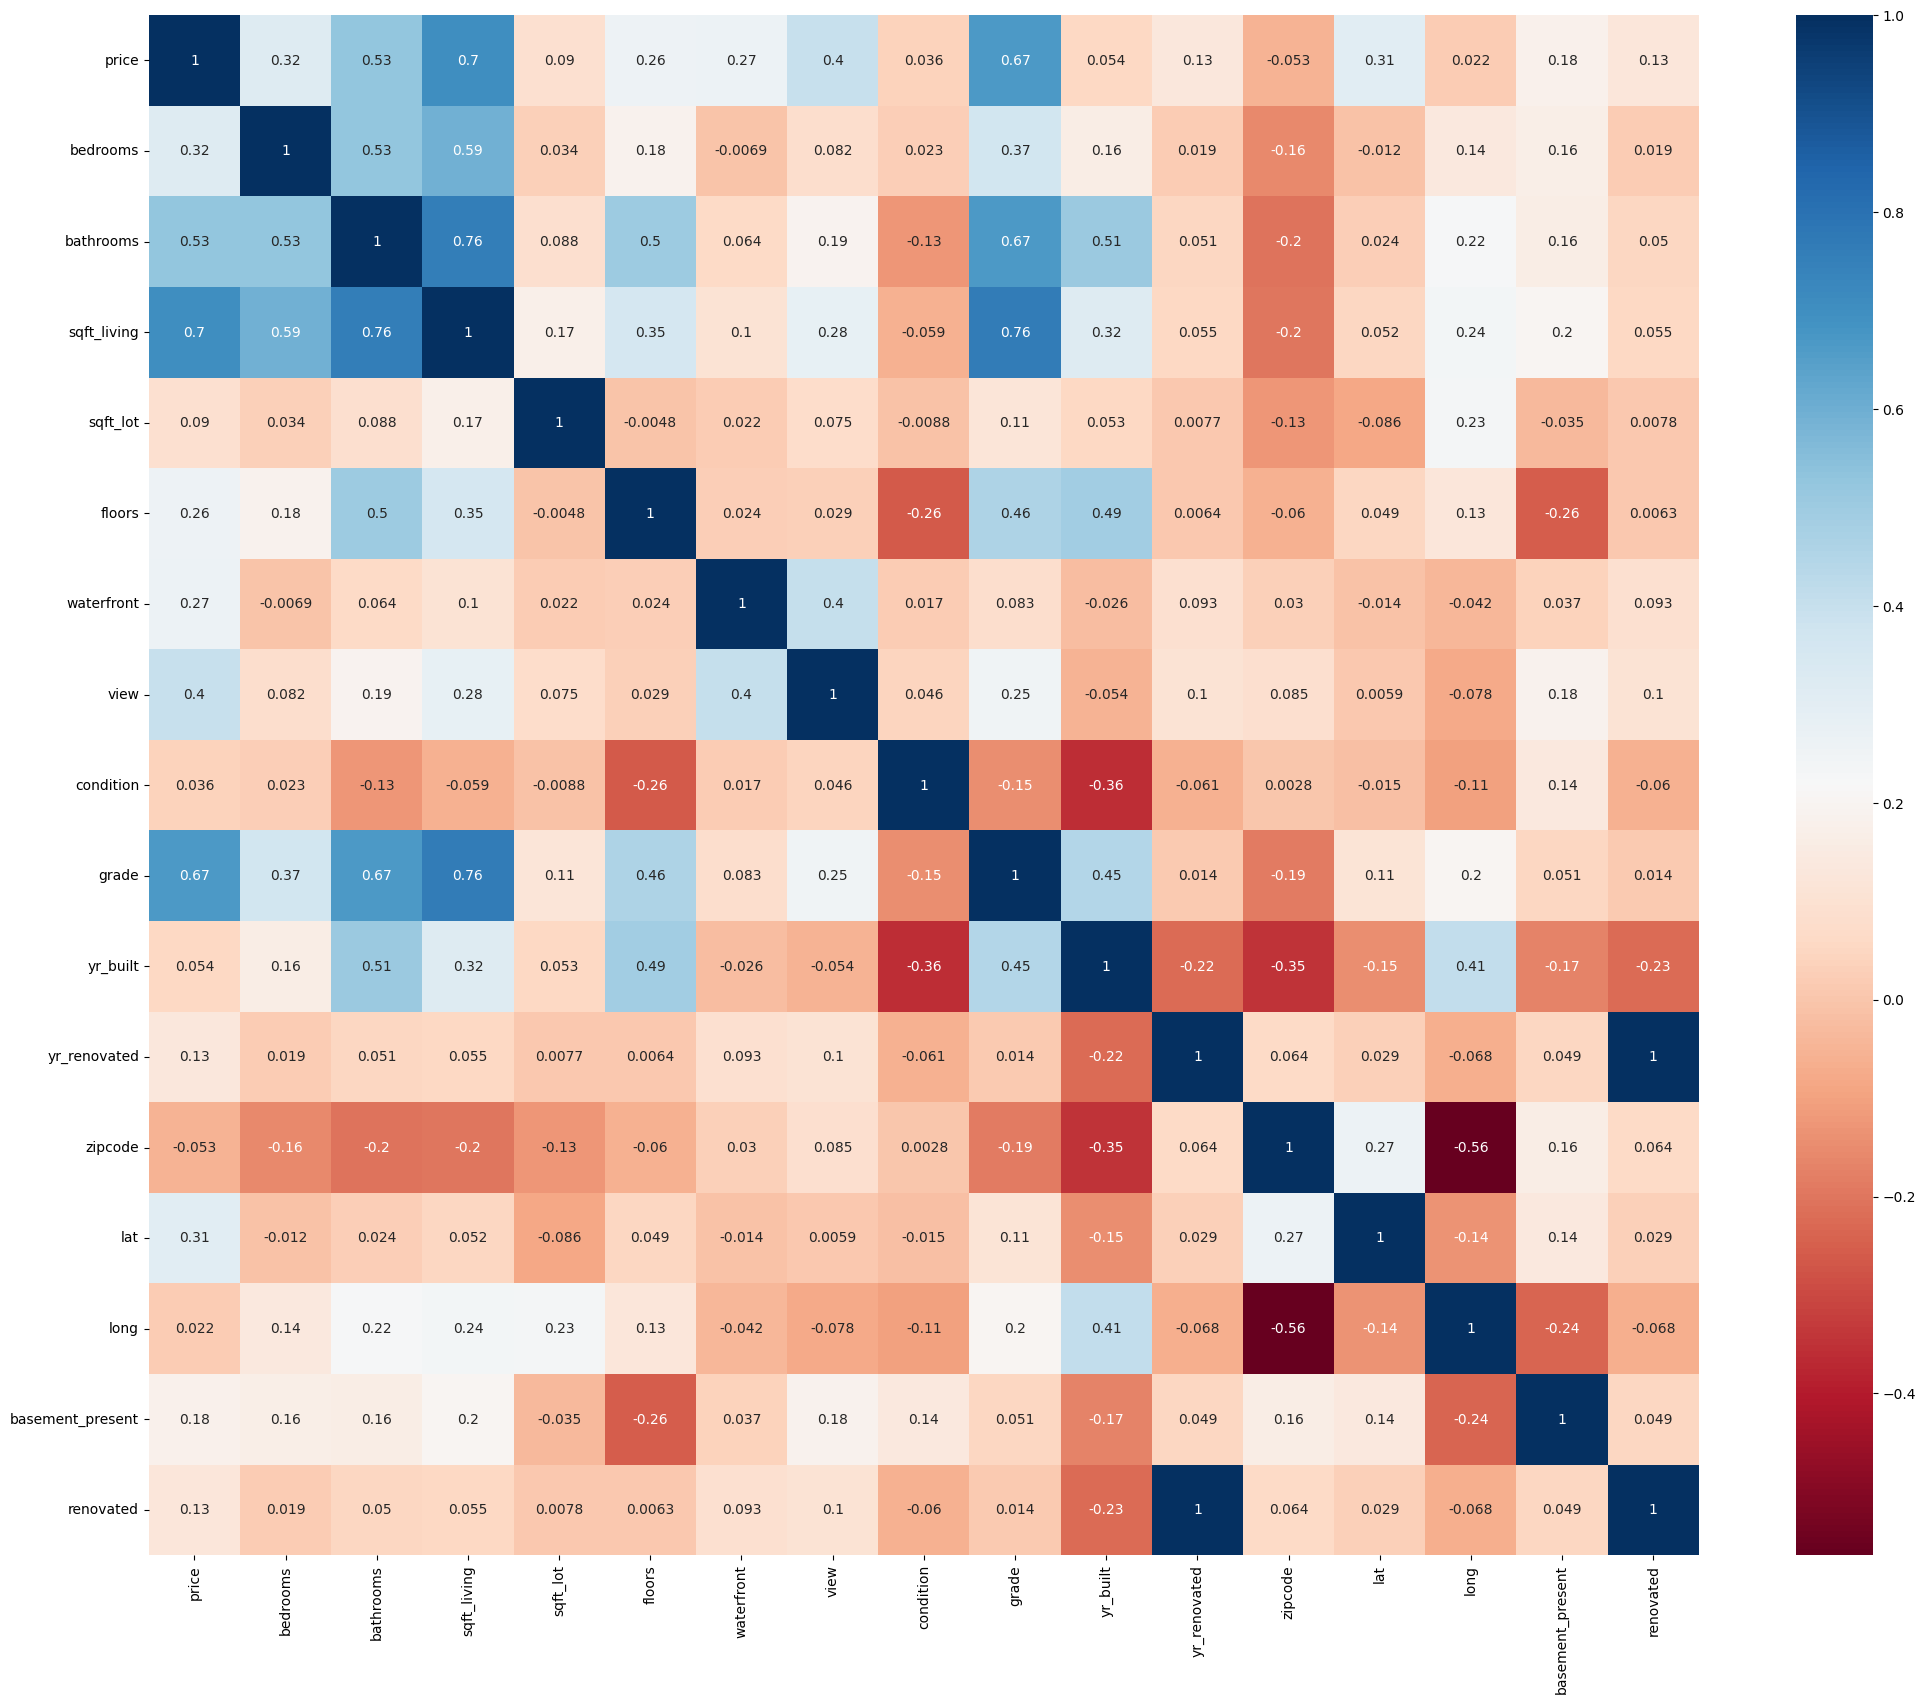

In [82]:
# Correlation matrix 
plt.figure(figsize = (25,20))
sns.heatmap(mydata.corr(), annot = True, cmap="RdBu")
plt.show()

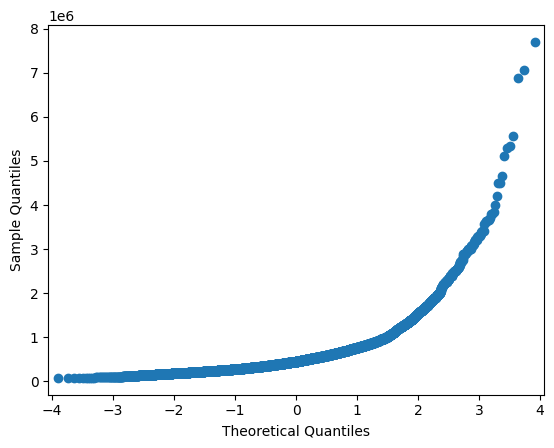

In [83]:
import statsmodels.api as sm
fig=sm.qqplot(mydata['price'])
plt.show()

# Based on the plot of QQ plot non normal distribution and from figure of price distribution there is outlier so we should use log  transformation 

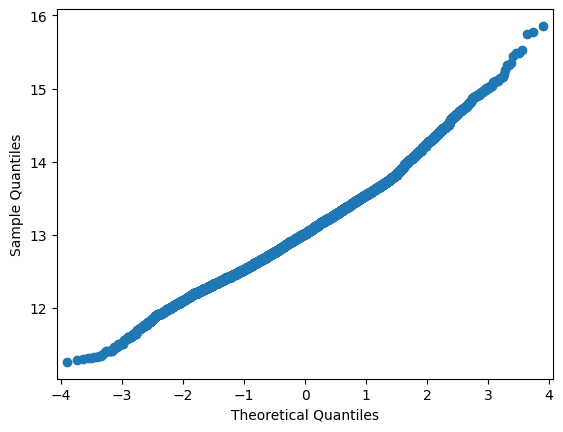

In [84]:
import numpy as np

fig=sm.qqplot(np.log(mydata['price']))
plt.show()

#it shows that log transformation would be better for the price variable: prefer approximately normal distribution.
# Adding a `logprice` variable to the dataframe:

In [85]:
mydata['logprice']= np.log(mydata['price'])

In [86]:
mydata.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,yr_built,yr_renovated,zipcode,lat,long,basement_present,renovated,logprice
0,221900.0,3,1.00,1180,5650,1.0,False,0,3,7,1955,0,98178,47.5112,-122.257,0,0,12.309982
1,538000.0,3,2.25,2570,7242,2.0,False,0,3,7,1951,1991,98125,47.7210,-122.319,1,1,13.195614
2,180000.0,2,1.00,770,10000,1.0,False,0,3,6,1933,0,98028,47.7379,-122.233,0,0,12.100712
3,604000.0,4,3.00,1960,5000,1.0,False,0,5,7,1965,0,98136,47.5208,-122.393,1,0,13.311329
4,510000.0,3,2.00,1680,8080,1.0,False,0,3,8,1987,0,98074,47.6168,-122.045,0,0,13.142166


Text(0.5, 0, 'logPrice ($)')

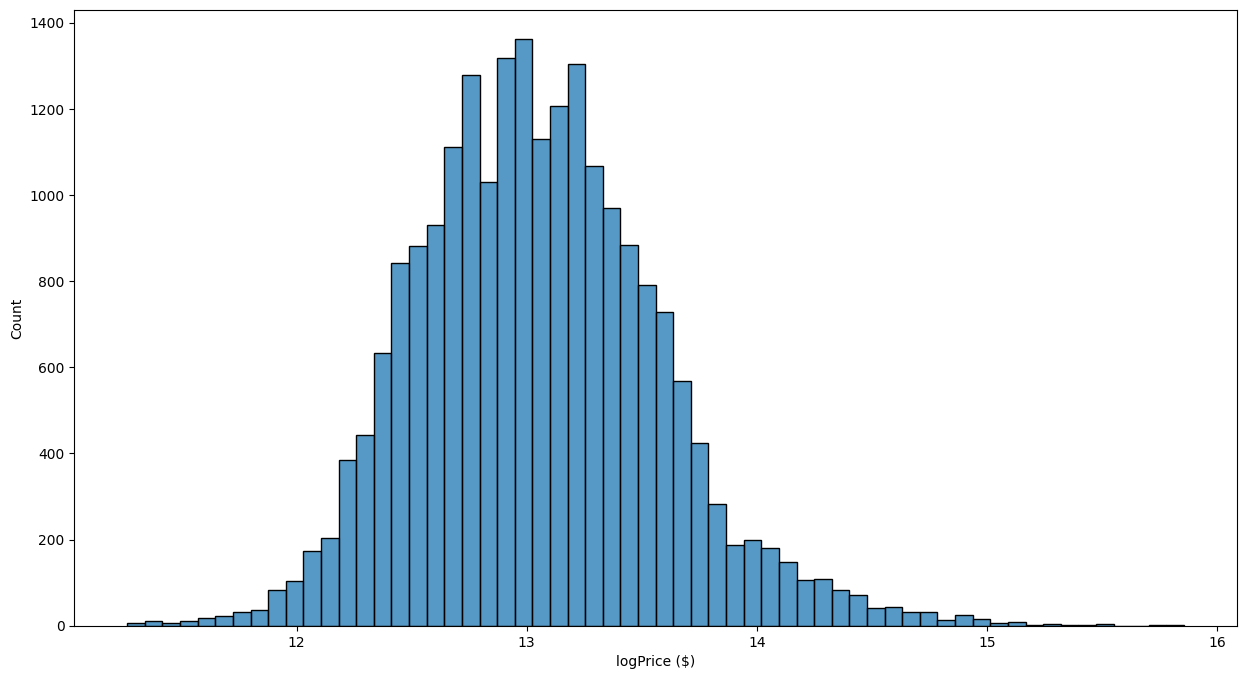

In [87]:
#after log transformation it look like approximately normal 
fig=plt.figure(figsize=[15,8])
sns.histplot(mydata['logprice'],bins=60)
plt.ticklabel_format(style='plain')
plt.xlabel("logPrice ($)")

In [88]:
# Select only numeric columns before aggregation
mydata.groupby("waterfront")[mydata.select_dtypes(include=[np.number]).columns].mean().T

waterfront,False,True
price,531667.833061,1.661876e+06
bedrooms,3.372370,3.300613e+00
bathrooms,2.111569,2.677914e+00
sqft_living,2072.028181,3.173687e+03
sqft_lot,15021.710586,2.537183e+04
floors,1.493001,1.641104e+00
view,0.207437,3.766871e+00
condition,3.408809,3.533742e+00
grade,7.649466,8.773006e+00
yr_built,1971.067793,1.962190e+03


<Axes: >

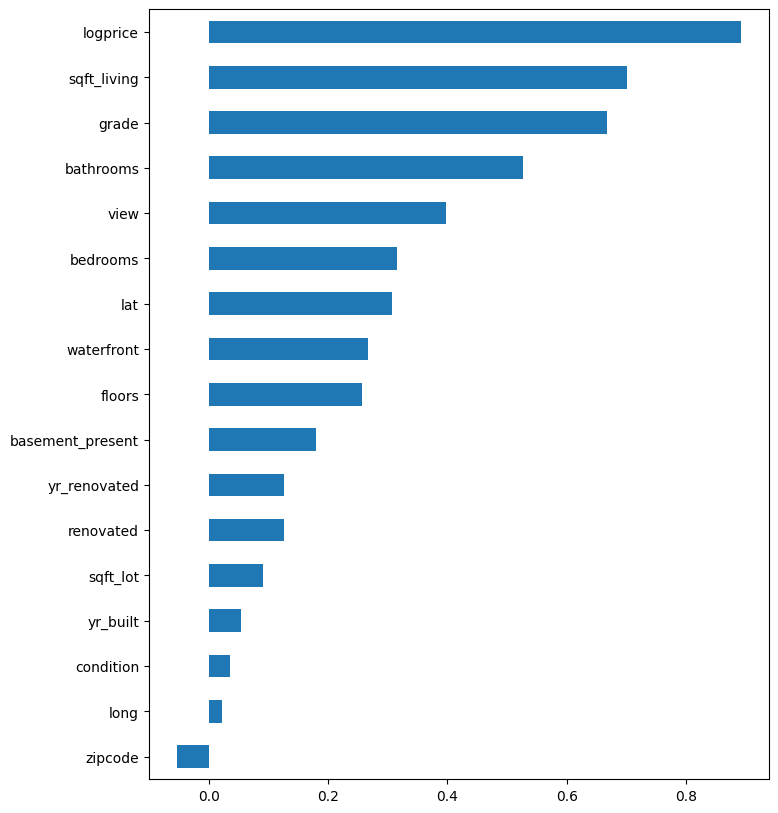

In [89]:
plt.figure(figsize = (8,10))
mydata.corr()["price"].sort_values().drop("price").plot(kind = "barh")

#Map Visualization 

In [90]:
import matplotlib.pyplot as plt
import plotly.express as px

In [91]:
smap = px.scatter_mapbox(mydata, lat="lat", lon="long", zoom=8.5, color="logprice",hover_name="zipcode", 
                         hover_data=["sqft_lot", "sqft_living", "price", "condition"],
                         labels={"sqft_lot":"Lot Size","sqft_living": "Home size", "price": "Sale Price"}, 
                         color_continuous_scale= "viridis_r", opacity=.8)
smap.update_layout(mapbox_style="carto-positron", height=500)
smap.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
smap.show()

C:\Users\Owner\AppData\Local\Temp\ipykernel_29312\2156174394.py:1: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



#Scatter plot price vs explanatory variables

<Figure size 1200x600 with 0 Axes>

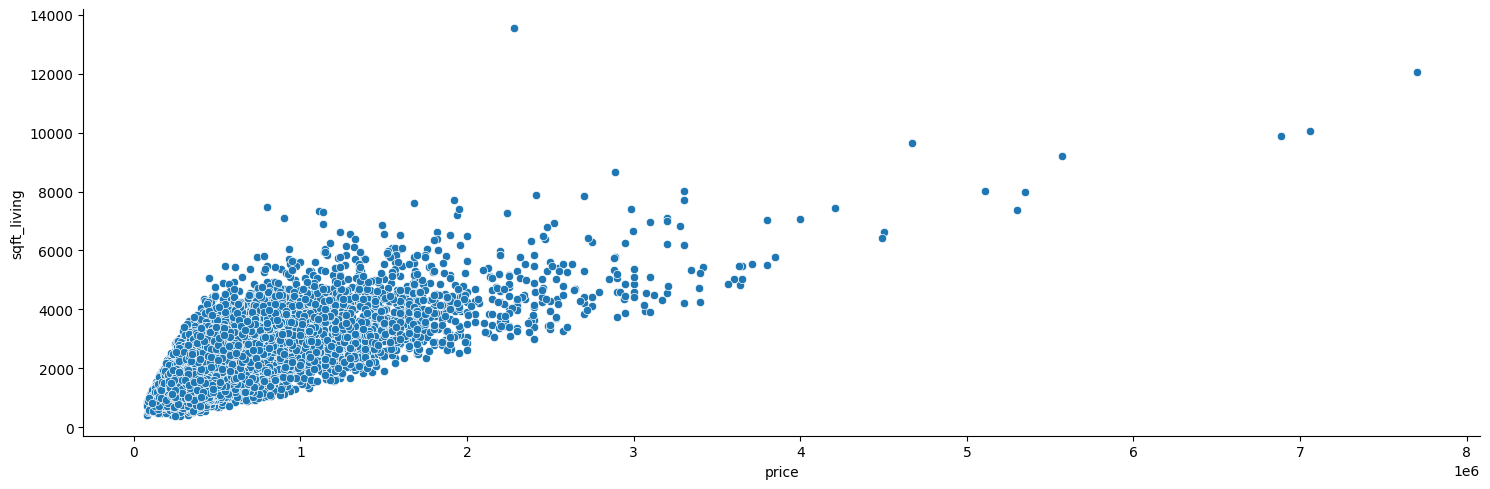

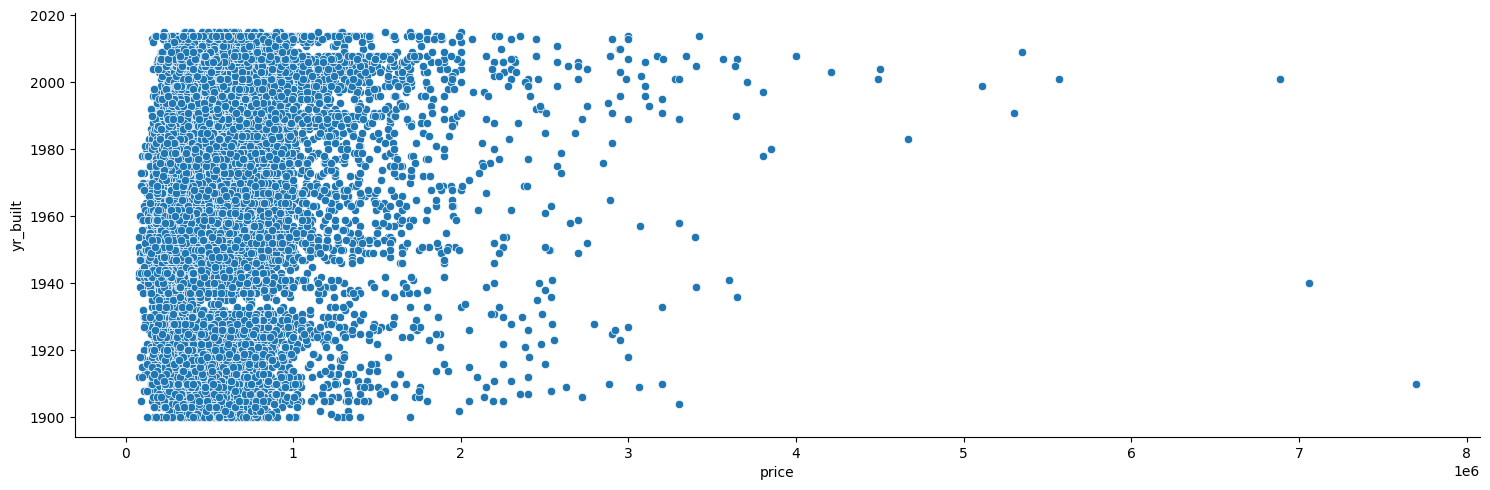

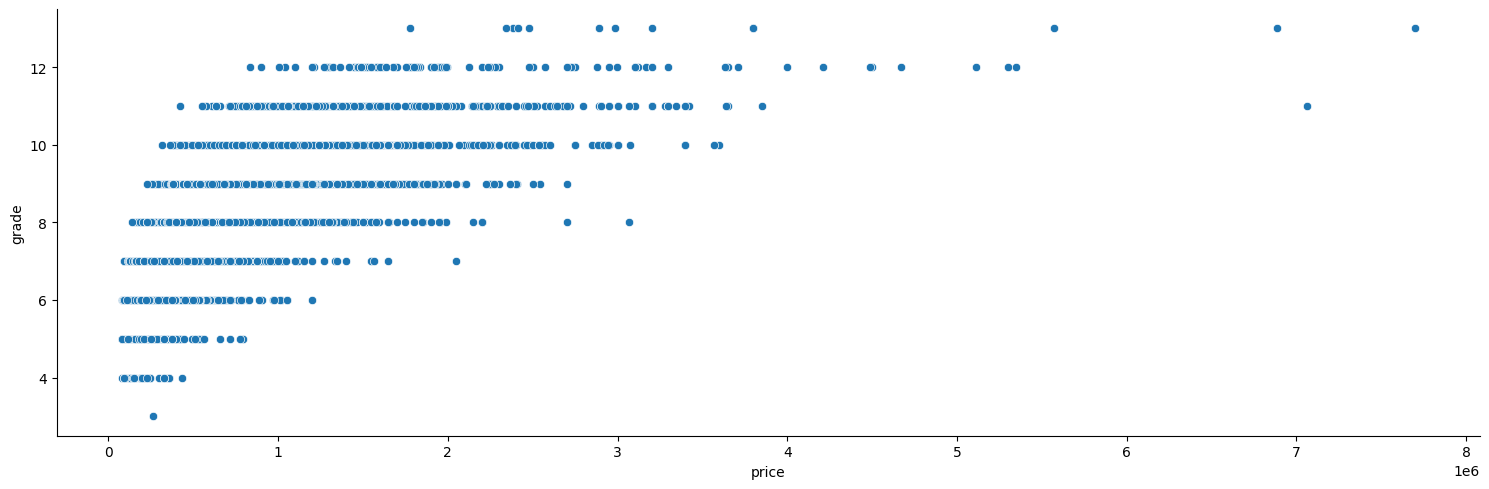

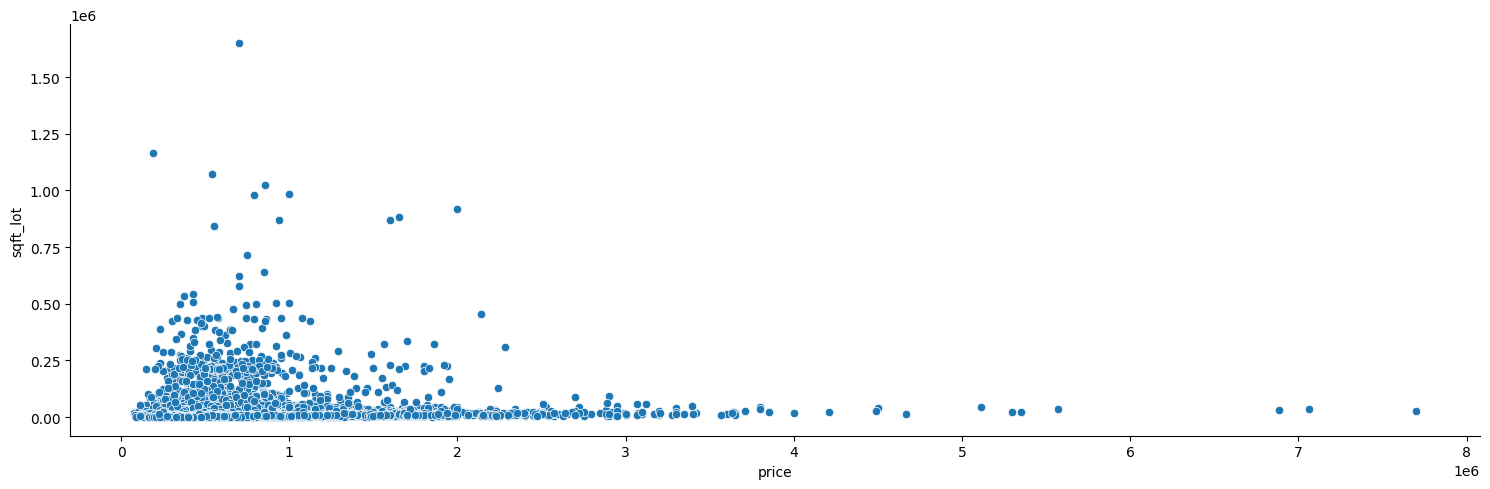

In [92]:
plt.figure(figsize=(12, 6))
for numerical_feature in ['sqft_living','yr_built', 'grade','sqft_lot']:
    sns.relplot(kind='scatter', x='price', y=numerical_feature, data = mydata, aspect=3)

<Figure size 1200x600 with 0 Axes>

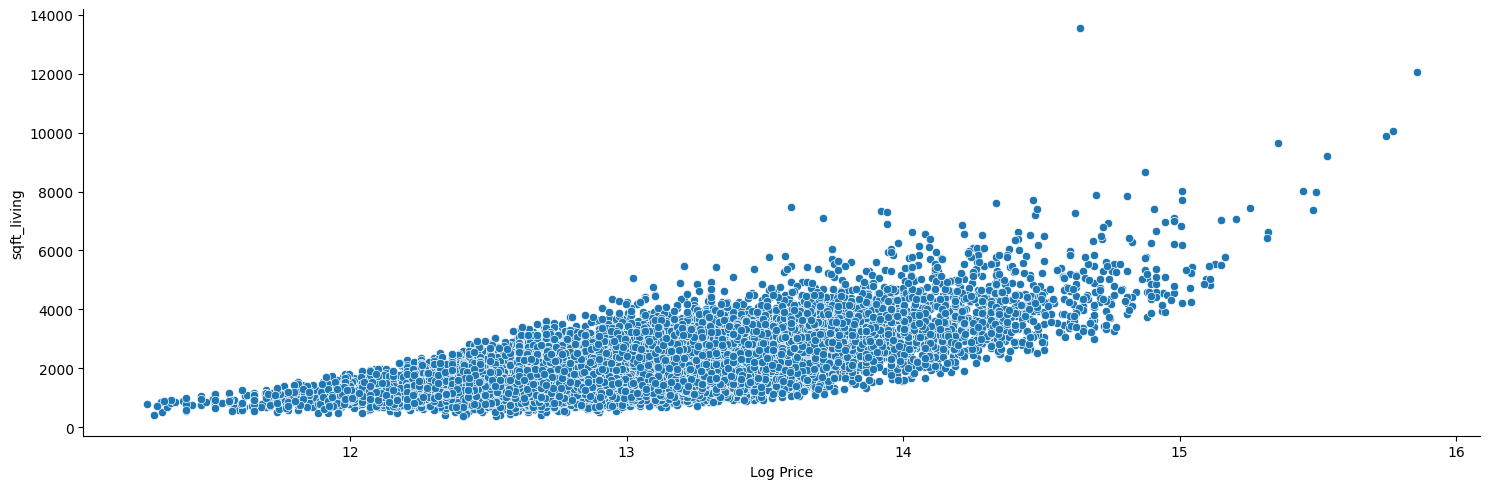

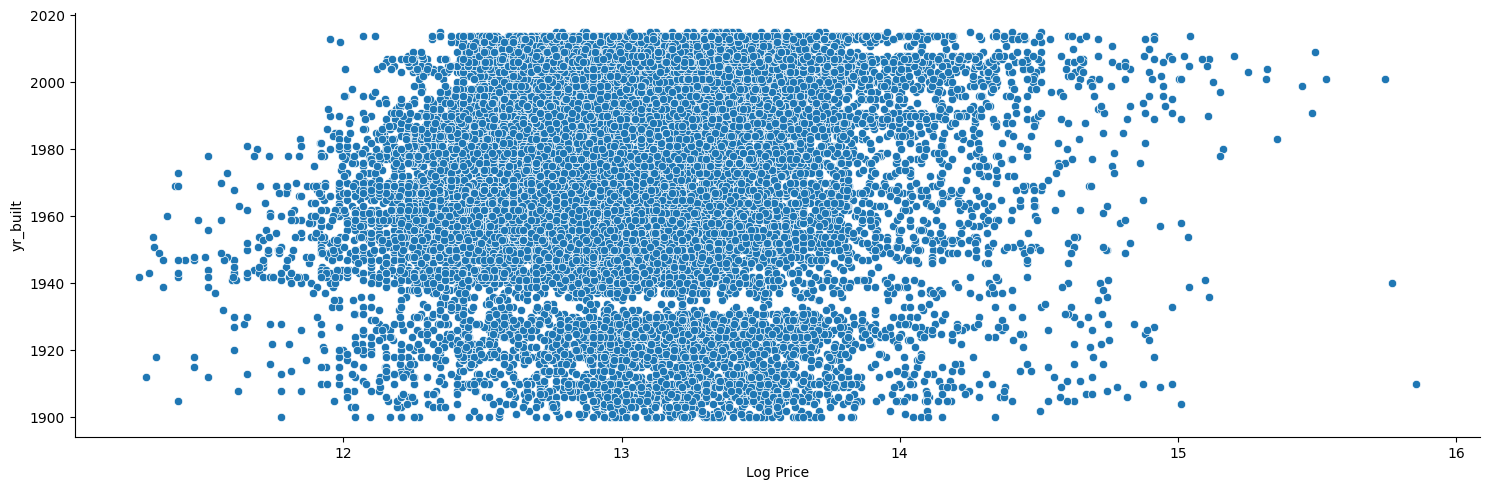

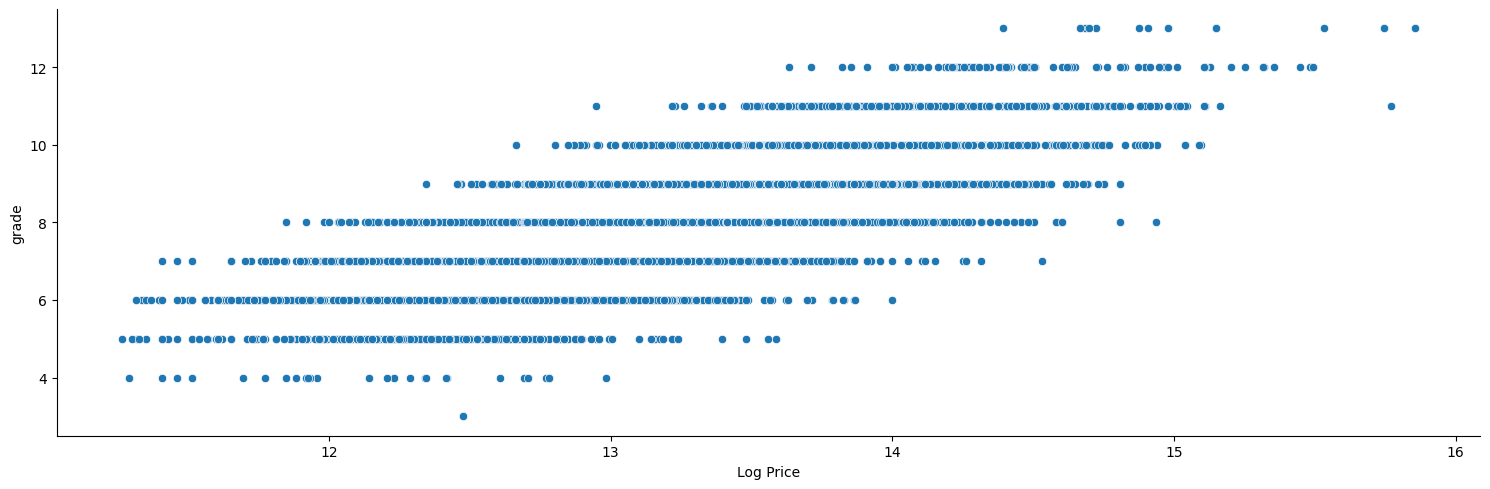

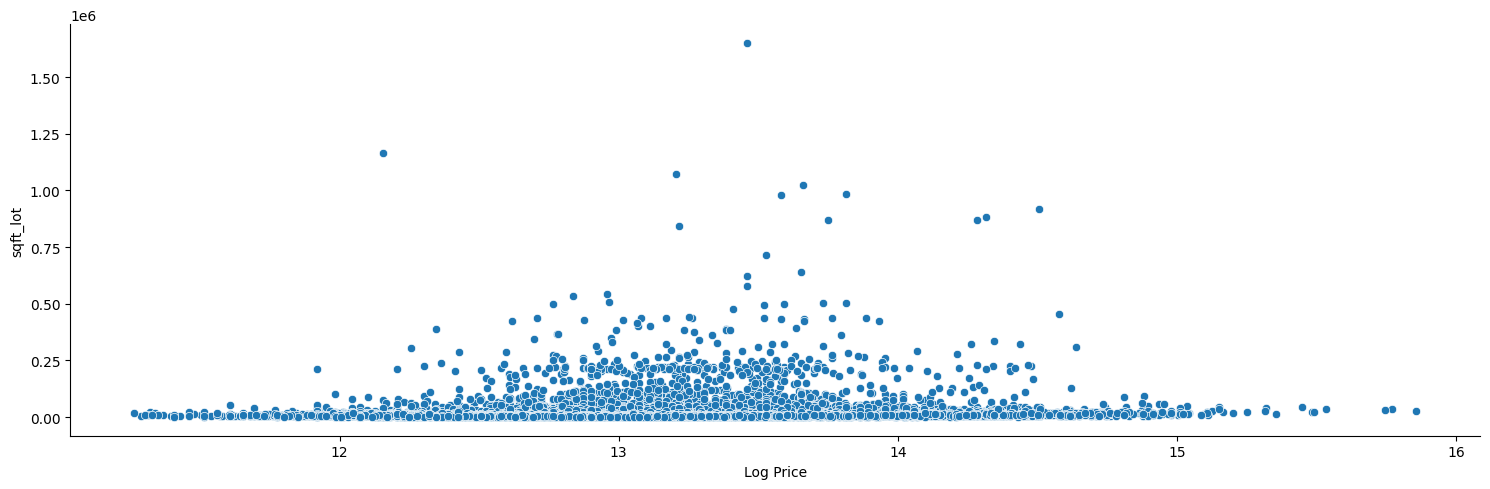

In [93]:
# The same thing as above, just on a log scale for price
plt.figure(figsize=(12, 6))
for numerical_feature in ['sqft_living','yr_built', 'grade','sqft_lot']:
    sns.relplot(kind='scatter', x='logprice', y=numerical_feature, data = mydata, aspect=3)
    plt.xlabel("Log Price")

Text(0.5, 0, 'Bedrooms&Bathrooms')

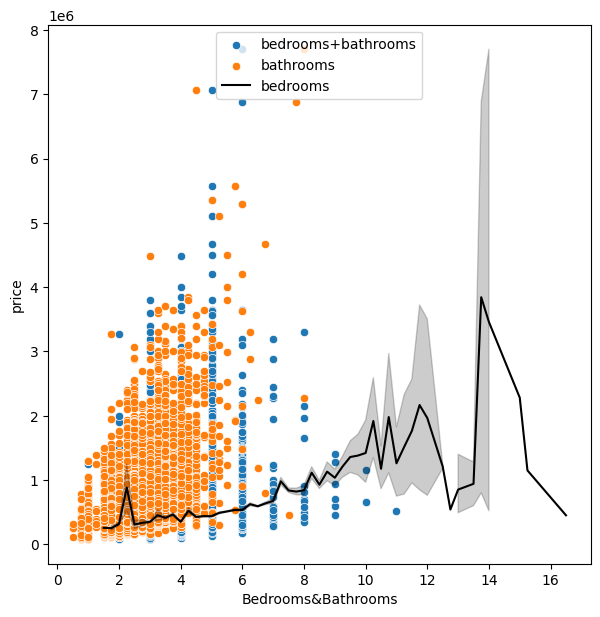

In [94]:
plt.figure(121,figsize=(7,7))
sns.scatterplot(x=mydata["bedrooms"],y=mydata["price"])
sns.scatterplot(x=mydata["bathrooms"],y=mydata["price"])
sns.lineplot(x=(mydata["bedrooms"]+mydata["bathrooms"]),y=mydata["price"],color="black");
plt.legend(["bedrooms+bathrooms","bathrooms","bedrooms"],loc="best");
plt.xlabel("Bedrooms&Bathrooms")

<Axes: xlabel='price', ylabel='long'>

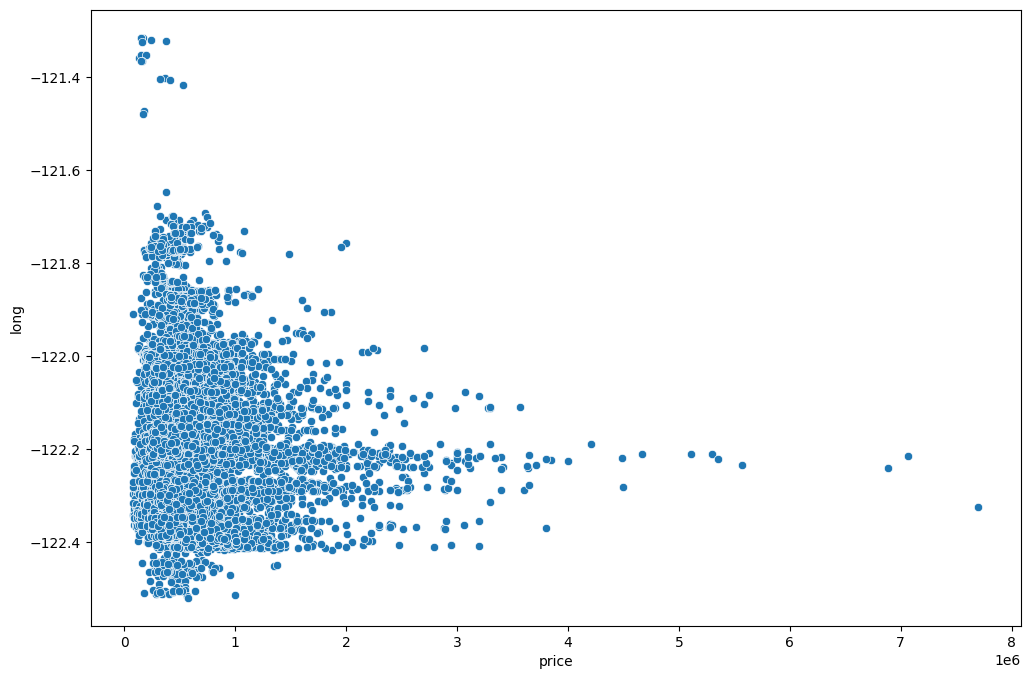

In [95]:
plt.figure(figsize = (12, 8))
sns.scatterplot(x = 'price', y = 'long', data = mydata)

<Axes: xlabel='logprice', ylabel='long'>

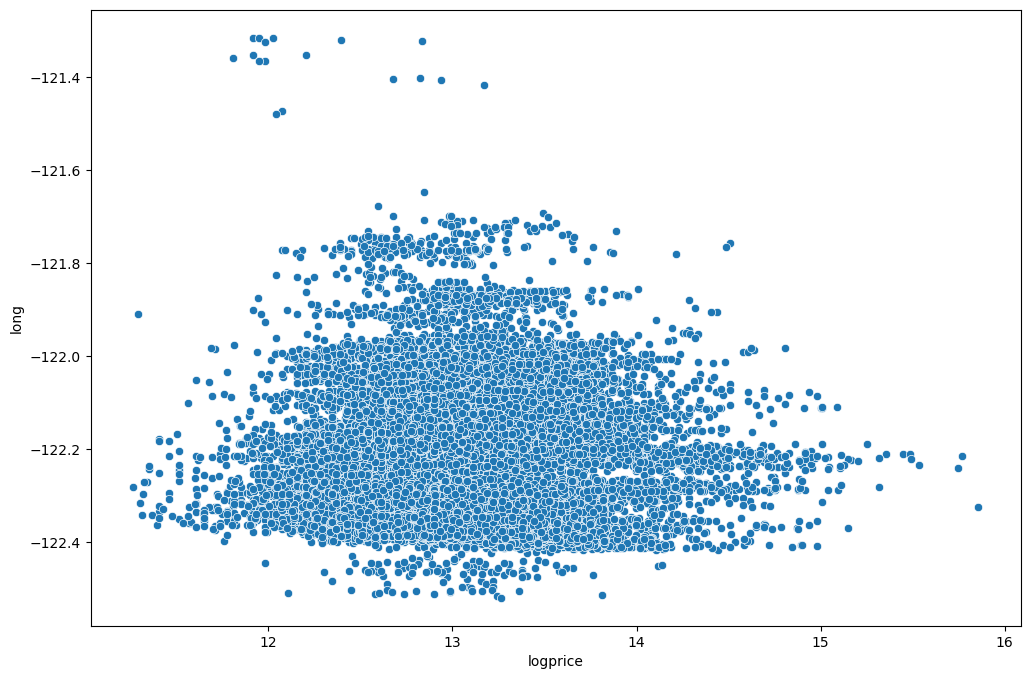

In [96]:
plt.figure(figsize = (12, 8))
sns.scatterplot(x = 'logprice', y = 'long', data = mydata)

<Axes: xlabel='price', ylabel='lat'>

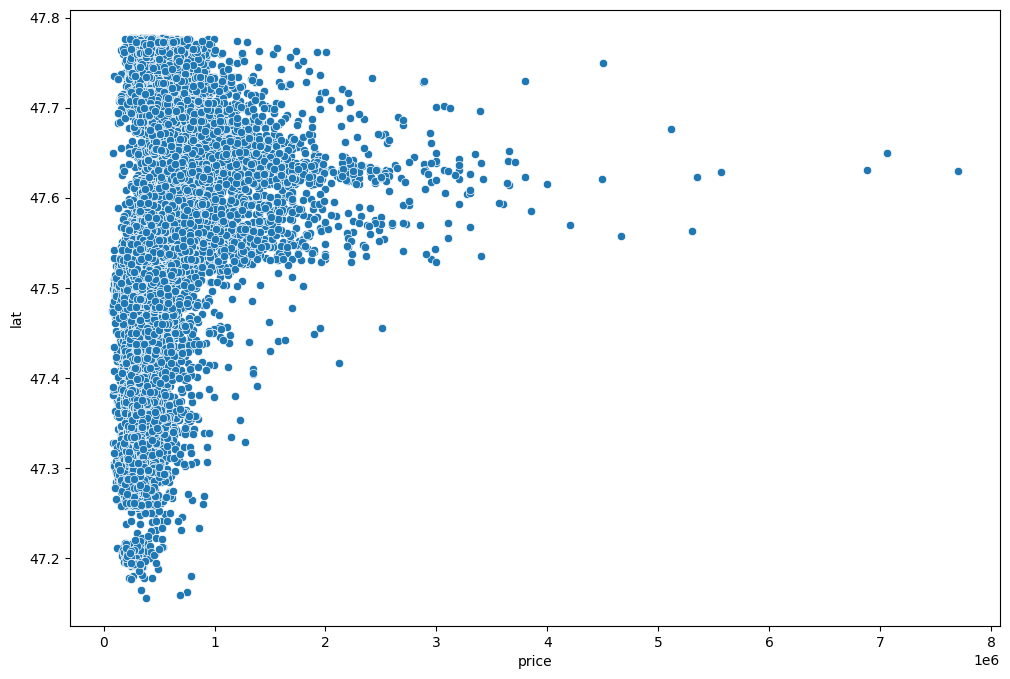

In [97]:
plt.figure(figsize  = (12, 8))
sns.scatterplot(x = 'price', y = 'lat', data = mydata)

<Axes: xlabel='logprice', ylabel='lat'>

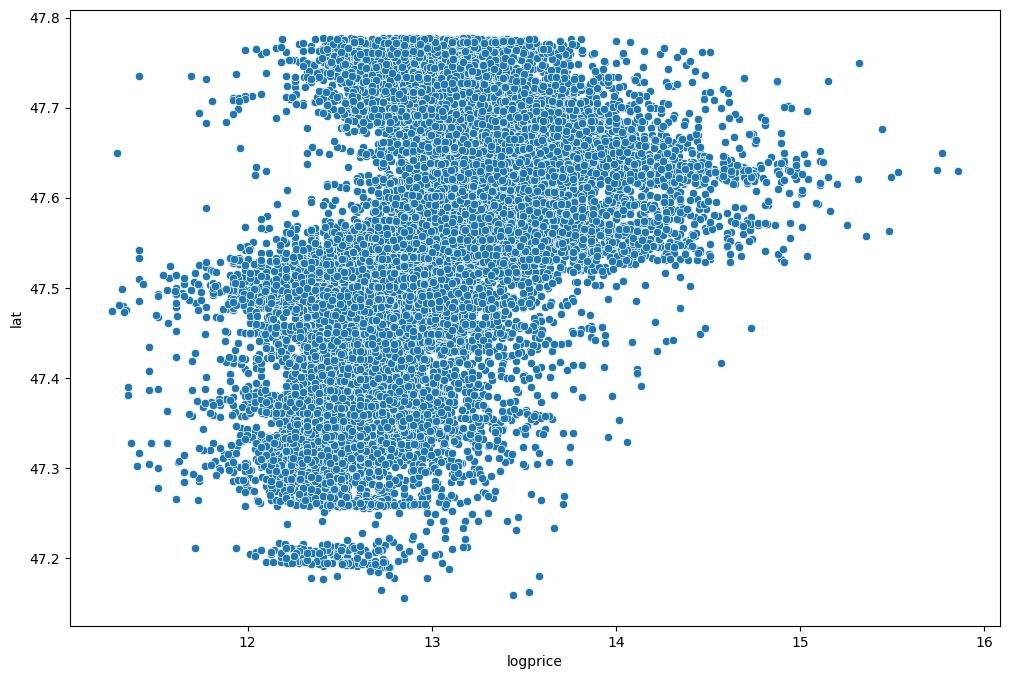

In [98]:
plt.figure(figsize = (12, 8))
sns.scatterplot(x = 'logprice', y = 'lat', data = mydata)

<Axes: xlabel='long', ylabel='lat'>

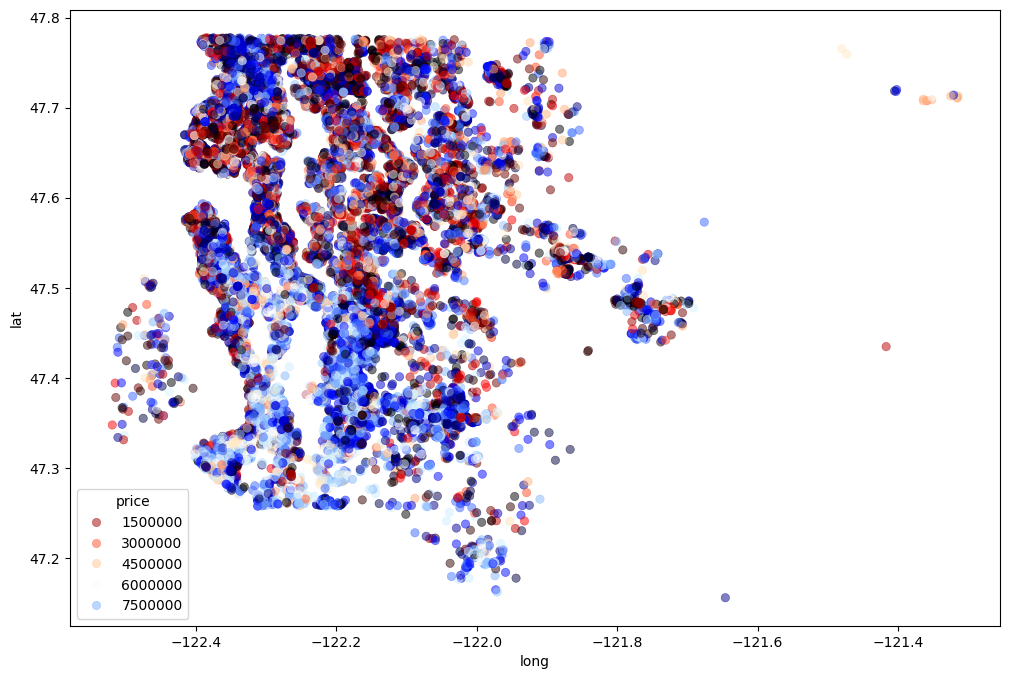

In [99]:
plt.figure(figsize = (12, 8))
sns.scatterplot(x = 'long', y = 'lat', data = mydata, hue = 'price',
                palette = 'flag', edgecolor = None, alpha = 0.5)

#Box plot 

In [100]:
import plotly.graph_objs as go
from plotly.offline import init_notebook_mode,iplot
fig1 = [go.Box(y=mydata.bedrooms,name="Bedrooms",marker=dict(color="green"),hoverinfo="name+y")]
fig2 = [go.Box(y=mydata.bathrooms,name="Bathrooms",marker=dict(color="yellow"),hoverinfo="name+y")]
layout2 = go.Layout(title="Bedrooms vs Bathrooms ",yaxis=dict(range=[0,13])) 
fig3 = go.Figure(data= fig1+fig2,layout=layout2)
iplot(fig3)

<Figure size 1200x600 with 0 Axes>

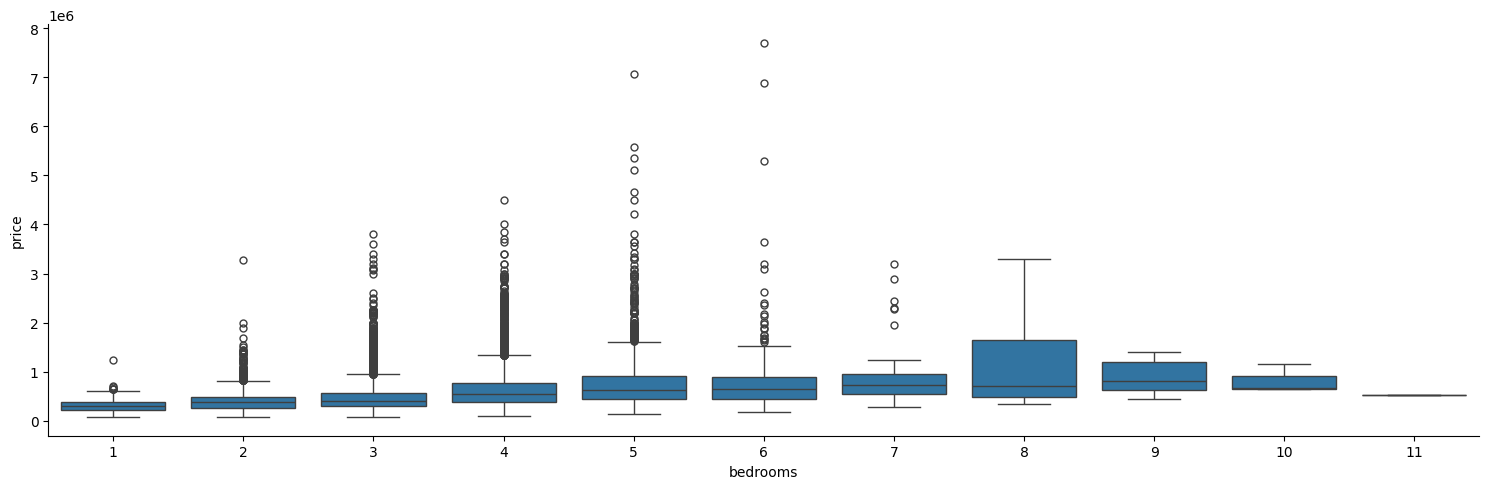

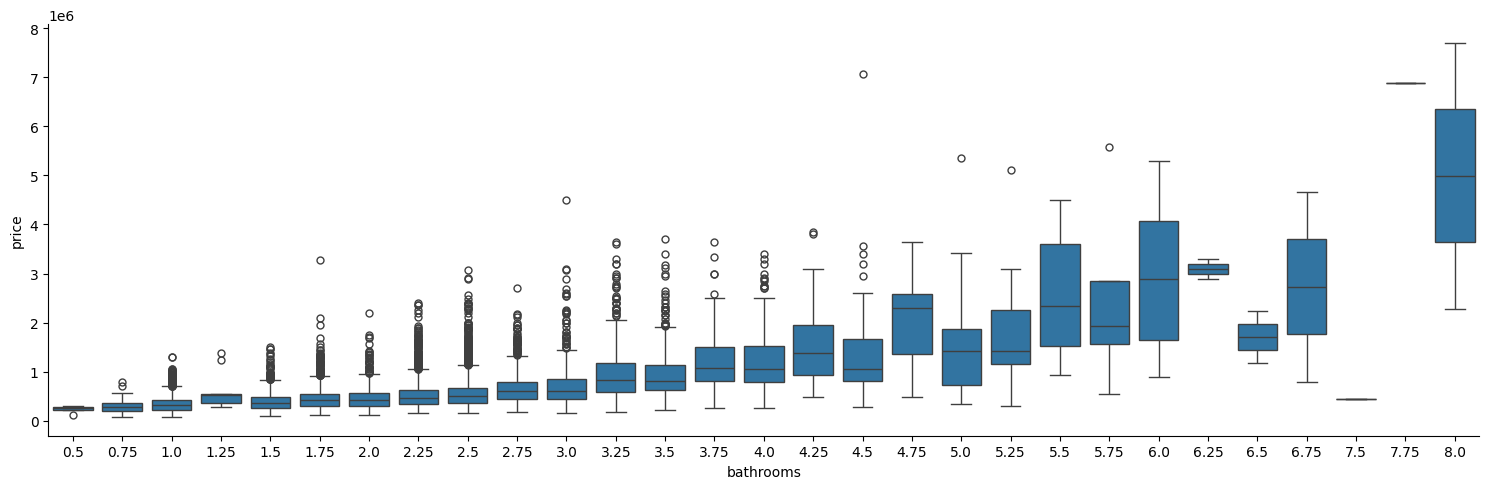

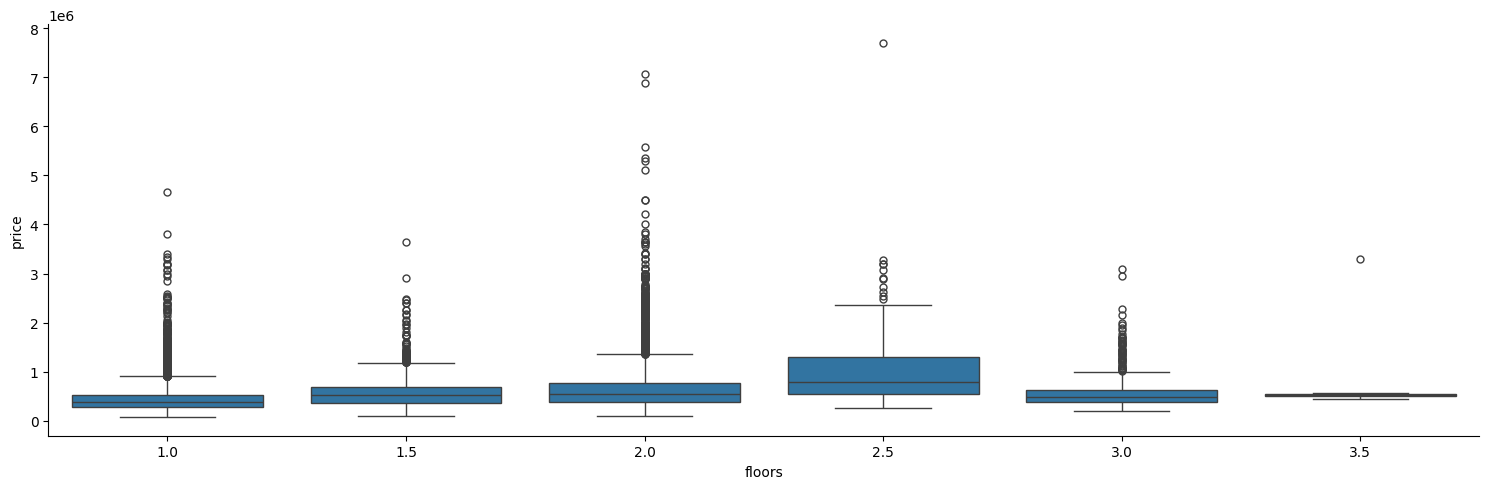

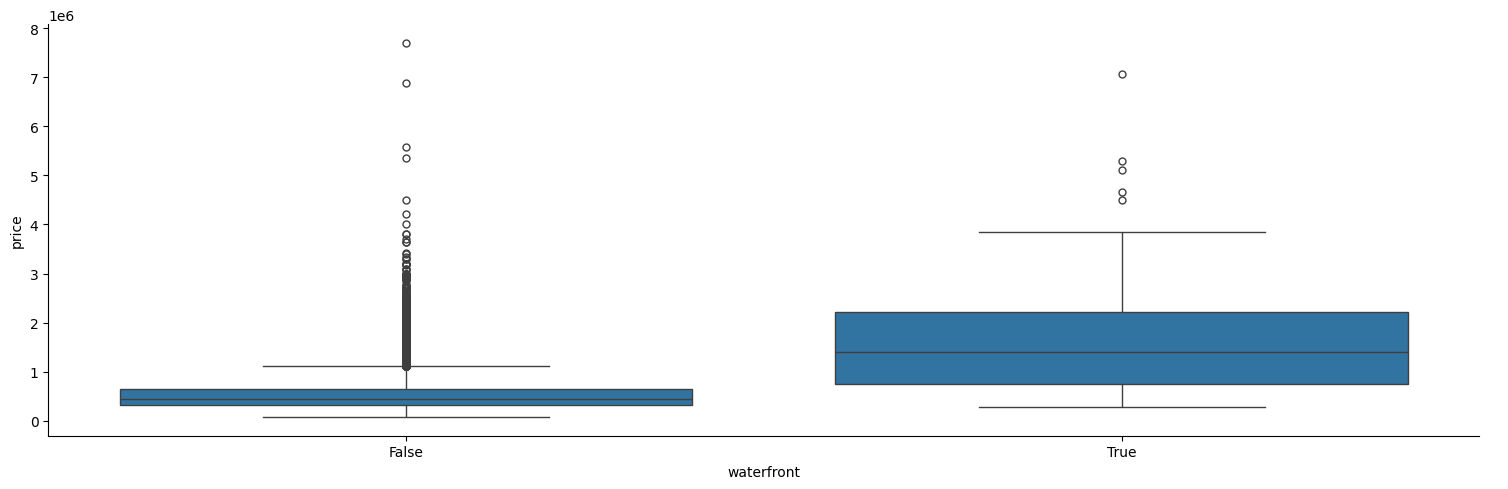

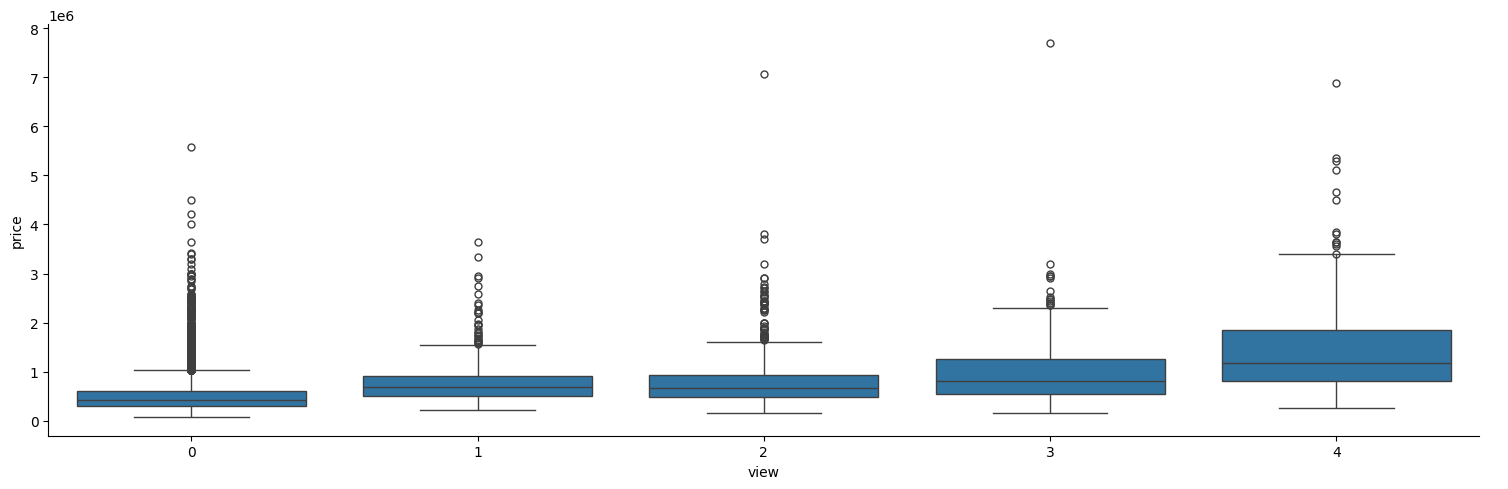

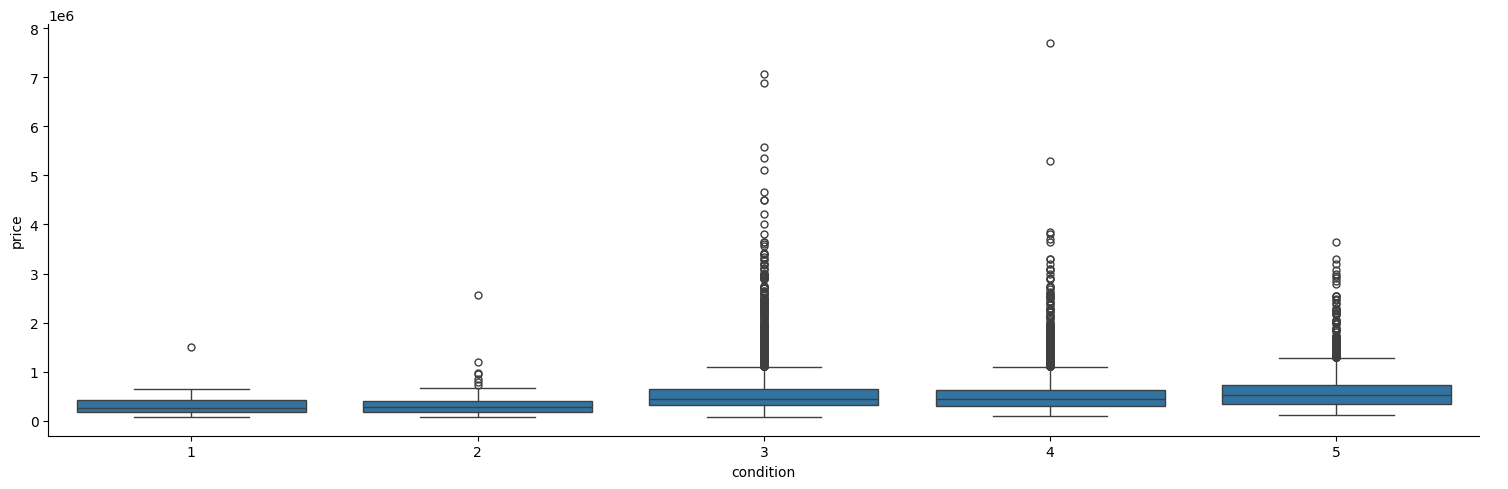

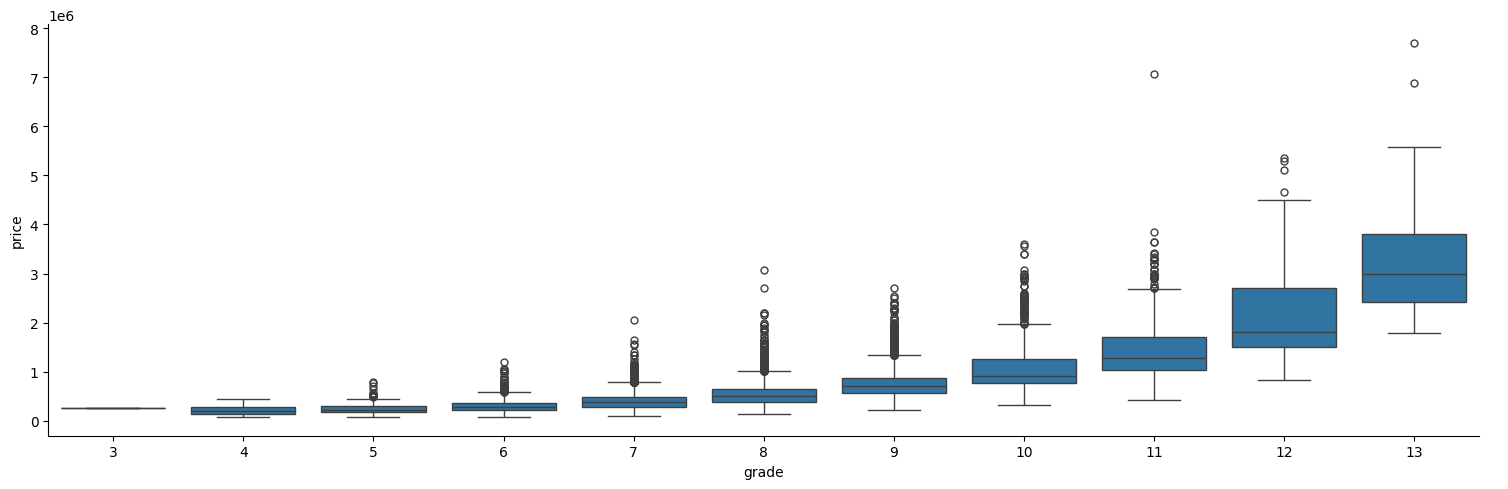

In [101]:
plt.figure(figsize=(12, 6))
for categorical_feature in ['bedrooms', 'bathrooms', 'floors', 'waterfront', 'view', 'condition', 'grade']:
    sns.catplot(kind='box', x=categorical_feature, y='price', data=mydata, aspect=3)

<Figure size 1200x600 with 0 Axes>

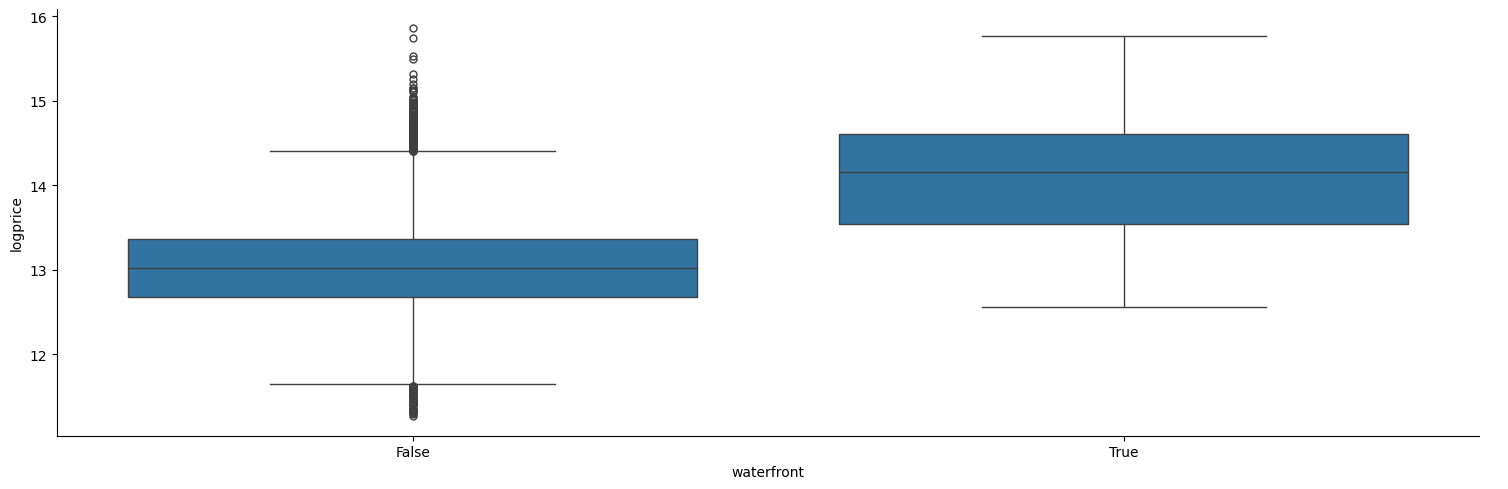

In [102]:
plt.figure(figsize=(12, 6))
sns.catplot(kind='box', x="waterfront", y='logprice', data=mydata, aspect=3)

<Axes: xlabel='yr_built', ylabel='price'>

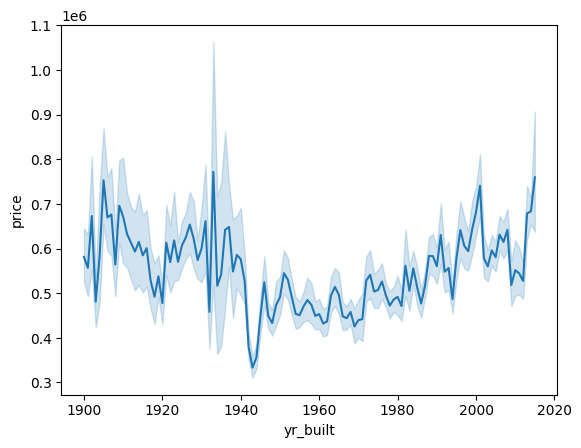

In [103]:
sns.lineplot(x= "yr_built", y= "price", data=mydata)

<Axes: title={'center': 'No Of Bathrooms in King county house'}, xlabel='bathrooms', ylabel='price'>

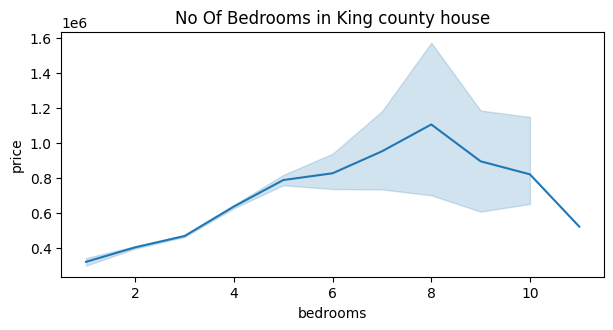

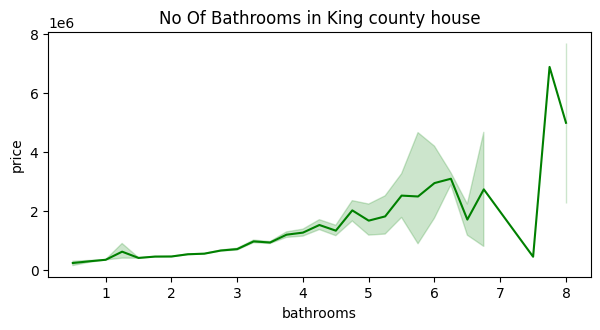

In [104]:
import matplotlib.pyplot as plt
plt.figure(figsize=[7,7]).add_subplot(211).set_title('No Of Bedrooms in King county house')
sns.lineplot(x=mydata['bedrooms'],y=mydata['price'],data=mydata,legend='full')
plt.figure(figsize=[7,7]).add_subplot(212).set_title('No Of Bathrooms in King county house')
sns.lineplot(x=mydata['bathrooms'],y=mydata['price'],data=mydata,legend='full',color='green')

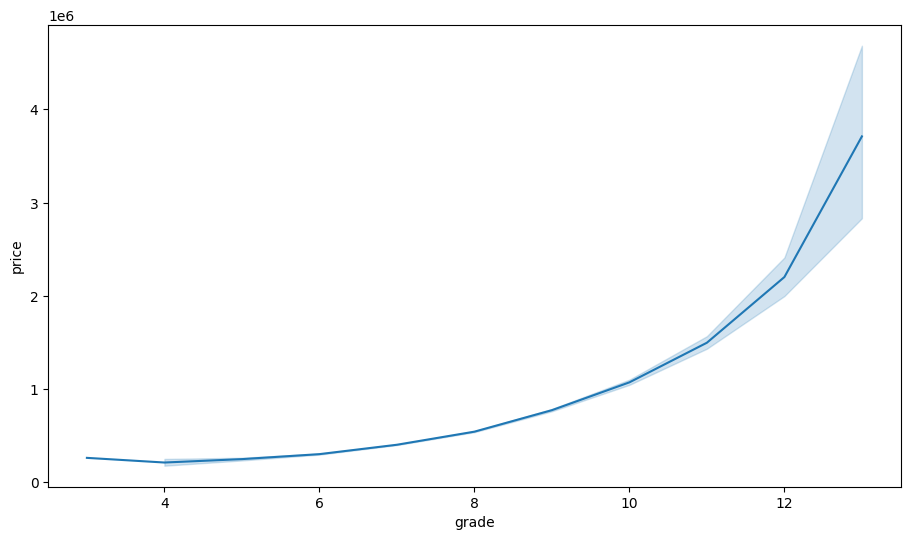

In [105]:
plt.figure(figsize=(11,6))
sns.lineplot(x='grade', y='price', data= mydata)
plt.show()

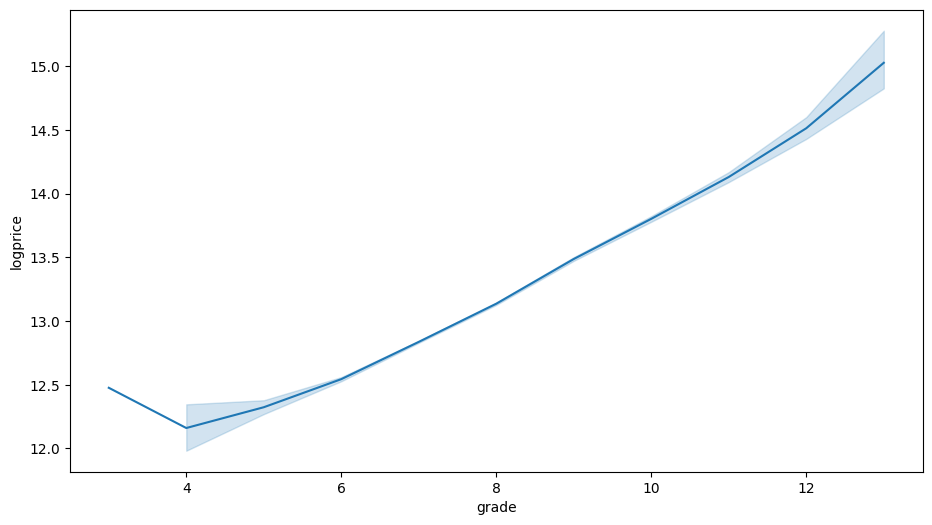

In [106]:
# Line plot after log transformation of price 
plt.figure(figsize=(11,6))
sns.lineplot(x='grade', y='logprice', data= mydata)
plt.show()

# getting to know the location by their zip code 
## Zipcode: `value_counts()` tells us number of zipcodes = 70
checking the distribution of the zipcode data either even or uneven

In [107]:
mydata['zipcode'].value_counts()

zipcode
98103    601
98038    589
98115    583
98052    574
98117    553
        ... 
98102    104
98010    100
98024     80
98148     57
98039     50
Name: count, Length: 70, dtype: int64

<Figure size 1000x700 with 0 Axes>

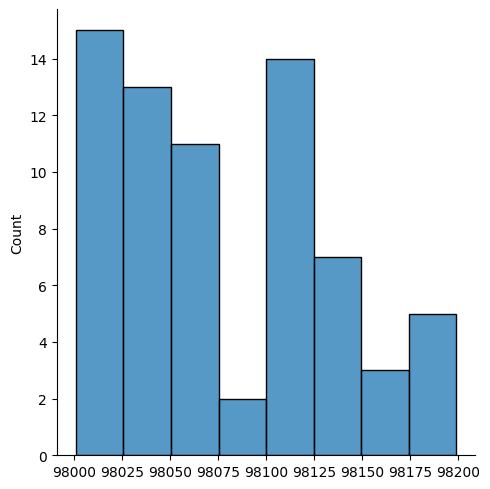

In [108]:
mydata['zipcode'].unique()
plt.figure(figsize=[10,7])
sns.displot(x=mydata['zipcode'].unique())

In [109]:
# on column zip code 
mydata['zipcode'].unique().max() # 98199
mydata['zipcode'].unique().min() # 98001
mydata['zipcode'].unique()

array([98178, 98125, 98028, 98136, 98074, 98053, 98003, 98198, 98146,
       98038, 98007, 98115, 98107, 98126, 98019, 98103, 98002, 98133,
       98040, 98092, 98030, 98119, 98112, 98052, 98027, 98117, 98058,
       98001, 98056, 98166, 98023, 98070, 98148, 98105, 98042, 98008,
       98059, 98122, 98144, 98004, 98005, 98034, 98075, 98116, 98010,
       98118, 98199, 98032, 98045, 98102, 98077, 98108, 98168, 98177,
       98065, 98029, 98006, 98109, 98022, 98033, 98155, 98024, 98011,
       98031, 98106, 98072, 98188, 98014, 98055, 98039])

### We can also learn the mean price, lot size, etc. by zipcode

In [111]:
zipcode = mydata.groupby(['zipcode'])[mydata.select_dtypes(include=[np.number]).columns].mean()
zipcode.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,view,condition,grade,yr_built,zipcode,lat,long,basement_present,renovated,logprice
zipcode,,,,,,,,,,,,,,,,
98001,2.811949e+05,3.393352,2.011773,1903.783934,14967.002770,1.430748,0.102493,3.335180,7.296399,1980.867036,98001.0,47.309106,-122.270704,0.240997,0.022161,12.493124
98002,2.342840e+05,3.326633,1.839196,1627.743719,7517.633166,1.334171,0.010050,3.743719,6.693467,1967.773869,98002.0,47.308780,-122.213357,0.155779,0.030151,12.337702
98003,2.941113e+05,3.357143,2.047321,1928.882143,10603.096429,1.310714,0.214286,3.371429,7.542857,1976.885714,98003.0,47.315741,-122.310054,0.357143,0.010714,12.539857
98004,1.355927e+06,3.854890,2.527603,2909.022082,13104.220820,1.432177,0.305994,3.495268,8.687697,1971.470032,98004.0,47.616183,-122.205189,0.466877,0.104101,14.008379
98005,8.101649e+05,3.851190,2.424107,2656.803571,19928.785714,1.279762,0.095238,3.696429,8.488095,1969.744048,98005.0,47.611532,-122.167268,0.517857,0.023810,13.560104


In [115]:
# numeric columns except zipcode
num_cols = mydata.select_dtypes(include=[np.number]).columns.drop('zipcode', errors='ignore')

wfzips = (
    mydata.loc[mydata['waterfront'] == 1]
    .groupby('zipcode')[num_cols]
    .mean()
    .sort_values('price')
    .reset_index()
)


In [116]:
numerical = mydata[['price','bedrooms','bathrooms','sqft_living','sqft_lot','floors','waterfront','view','condition','grade','logprice','renovated','basement_present']]
numerical = numerical.corr().drop('price')
numerical[['price', 'logprice']].sort_values('logprice')

,price,logprice
condition,0.036000,0.038838
sqft_lot,0.089885,0.100029
renovated,0.126076,0.114103
waterfront,0.266438,0.174690
basement_present,0.180076,0.212152
floors,0.256831,0.310668
view,0.397323,0.346594
bedrooms,0.315966,0.350866
bathrooms,0.525915,0.551251
sqft_living,0.701921,0.695170


<Axes: >

<Figure size 2000x2000 with 0 Axes>

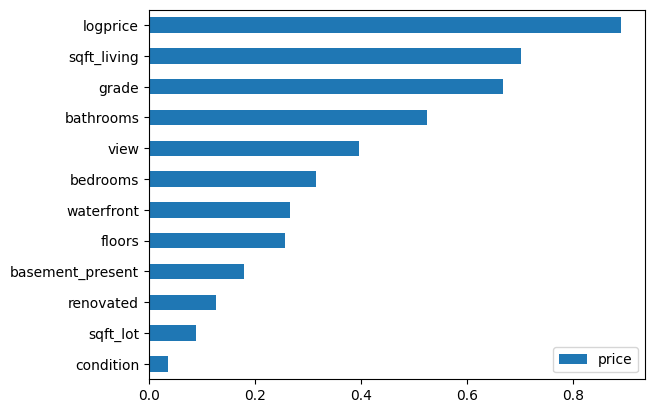

In [117]:
plt.figure(figsize=(20,20))
numerical[['price']].sort_values('price').plot(kind = "barh")

In [118]:
mydata.corr()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,yr_built,yr_renovated,zipcode,lat,long,basement_present,renovated,logprice
price,1.000000,0.315966,0.525915,0.701921,0.089885,0.256831,0.266438,0.397323,0.036000,0.667935,0.053995,0.126418,-0.053443,0.306772,0.022103,0.180076,0.126076,0.891720
bedrooms,0.315966,1.000000,0.527870,0.593178,0.033602,0.183707,-0.006869,0.082437,0.023440,0.366174,0.160736,0.019160,-0.158588,-0.011595,0.136561,0.164290,0.018864,0.350866
bathrooms,0.525915,0.527870,1.000000,0.755755,0.088368,0.502574,0.063742,0.188381,-0.126443,0.665834,0.507166,0.050540,-0.204778,0.024301,0.224889,0.162800,0.050060,0.551251
sqft_living,0.701921,0.593178,0.755755,1.000000,0.173449,0.353941,0.103853,0.284704,-0.059397,0.762776,0.318140,0.055303,-0.199793,0.052178,0.241200,0.204362,0.055034,0.695170
sqft_lot,0.089885,0.033602,0.088368,0.173449,1.000000,-0.004824,0.021631,0.074897,-0.008806,0.114726,0.052939,0.007684,-0.129582,-0.085507,0.230222,-0.035216,0.007786,0.100029
floors,0.256831,0.183707,0.502574,0.353941,-0.004824,1.000000,0.023752,0.028801,-0.264013,0.458783,0.489175,0.006418,-0.059522,0.049280,0.125912,-0.256507,0.006340,0.310668
waterfront,0.266438,-0.006869,0.063742,0.103853,0.021631,0.023752,1.000000,0.401970,0.016624,0.082886,-0.026157,0.092872,0.030274,-0.014302,-0.041908,0.037190,0.093281,0.174690
view,0.397323,0.082437,0.188381,0.284704,0.074897,0.028801,0.401970,1.000000,0.046041,0.251722,-0.053649,0.103948,0.084629,0.005884,-0.078120,0.181939,0.104093,0.346594
condition,0.036000,0.023440,-0.126443,-0.059397,-0.008806,-0.264013,0.016624,0.046041,1.000000,-0.146854,-0.361555,-0.060772,0.002835,-0.015209,-0.105800,0.135094,-0.060294,0.038838
grade,0.667935,0.366174,0.665834,0.762776,0.114726,0.458783,0.082886,0.251722,-0.146854,1.000000,0.447854,0.014256,-0.185761,0.113602,0.200324,0.051289,0.013848,0.703706


In [119]:
mydata.corr()['price'].sort_values(ascending=False)

price               1.000000
logprice            0.891720
sqft_living         0.701921
grade               0.667935
bathrooms           0.525915
view                0.397323
bedrooms            0.315966
lat                 0.306772
waterfront          0.266438
floors              0.256831
basement_present    0.180076
yr_renovated        0.126418
renovated           0.126076
sqft_lot            0.089885
yr_built            0.053995
condition           0.036000
long                0.022103
zipcode            -0.053443
Name: price, dtype: float64

In [120]:
#  the correlation between price and zipcode are negatives i want drop other negative correlations valus as well
#mydata = mydata.drop('zipcode', axis = 1)


# Modelling and Performance evaluation

# creat train and test split data
# The first step would be to create X and y


In [121]:
from sklearn import linear_model
import statsmodels.api as sm

In [122]:
mydata.isna().sum()

price               0
bedrooms            0
bathrooms           0
sqft_living         0
sqft_lot            0
floors              0
waterfront          0
view                0
condition           0
grade               0
yr_built            0
yr_renovated        0
zipcode             0
lat                 0
long                0
basement_present    0
renovated           0
logprice            0
dtype: int64

In [123]:
features = mydata.iloc[:, 3:].columns.tolist()
features

['sqft_living',
 'sqft_lot',
 'floors',
 'waterfront',
 'view',
 'condition',
 'grade',
 'yr_built',
 'yr_renovated',
 'zipcode',
 'lat',
 'long',
 'basement_present',
 'renovated',
 'logprice']

In [124]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [125]:
# Linear regression afte before logtransformation of house price 
y=mydata['price']
x=mydata[['bedrooms','bathrooms','sqft_living','sqft_lot','waterfront','floors',
            'view','condition','grade','yr_built','zipcode',
          'basement_present','yr_renovated','renovated','lat','long',]]

#splitting the data into training and tesing
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x,y,test_size=0.3,random_state=101)
print(f'Total # of sample in whole dataset: {len(x)}')
print("*****"*10)
print(f'Total # of sample in train dataset: {len(xtrain)}')
print(f'Shape of X_train: {xtrain.shape}')
print("*****"*10)
print(f'Total # of sample in test dataset: {len(xtest)}')
print(f'Shape of X_test: {xtest.shape}')

Total # of sample in whole dataset: 21596
**************************************************
Total # of sample in train dataset: 15117
Shape of X_train: (15117, 16)
**************************************************
Total # of sample in test dataset: 6479
Shape of X_test: (6479, 16)


In [126]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
xtrain=scaler.fit_transform(xtrain)
xtest=scaler.transform(xtest)

In [127]:
#linear regression model and training
from sklearn.linear_model import LinearRegression
LR=LinearRegression()

In [128]:
LR.fit(xtrain, ytrain)

LinearRegression()

In [129]:
#predicting price for test set
pred=LR.predict(xtest)

In [130]:
print(pred)

[ 593302.10515081  627256.38956754  614938.96263215 ... 2230877.98561131
  242497.31859545  153760.24733677]


In [131]:
from sklearn.metrics import r2_score,mean_squared_error, mean_absolute_error
print('Training r2_Score',LR.score(xtrain,ytrain))
print('Testing r2_Score ',LR.score(xtest,ytest))
#print('training mean square error', LR.mean_squared_error(xtrain,ytrain))

Training r2_Score 0.7001096503215504
Testing r2_Score  0.7003568888394642


In [132]:
#Results
train_score = LR.score(xtrain, ytrain)
print(f'Train score of trained model: {train_score*100}')

test_score = LR.score(xtest, ytest)
print(f'Test score of trained model: {test_score*100}')

Train score of trained model: 70.01096503215504
Test score of trained model: 70.03568888394642


In [133]:
from sklearn import metrics
metrics.mean_squared_error(ytest,pred)

40896849875.914566

In [134]:
#Adjusted R-square is used to provide us with a more unbiased picture as it punishes multicollinearity and gives a fair evaluation score. 
#To calculate Adjusted R2 we first calculate the variance of Y_test
var_test = ytest.var()
var_test

np.float64(136506268768.45131)

In [135]:
#We use the above-calculated variance to compute Adjusted R-square.
Adj_rsquare = 1-(metrics.mean_squared_error(ytest,pred)/var_test)
Adj_rsquare

np.float64(0.7004031371974145)

In [136]:
#Here we use numpy and metrics to calculate the RMSE.
np.sqrt(metrics.mean_squared_error(ytest,pred))

np.float64(202229.69583103905)

In [137]:
# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=150,max_depth=7)
rf = rf.fit(xtrain,ytrain)
ypred_rf = rf.predict(xtest)
print('Training r2_score',rf.score(xtrain,ytrain))
print('Testing r2_score',rf.score(xtest,ytest))

Training r2_score 0.872178405529389
Testing r2_score 0.829971876501929


In [138]:
#predicting price for test set for randomforest
pred_rf=rf.predict(xtest)

In [139]:
print(pred_rf)

[ 641068.97333209  606099.42812798  597690.58242247 ... 1949337.98161994
  290396.0977514   207724.77313808]


In [140]:
# Linear regression after logtransformation of the house price 
y=mydata['logprice']
x=mydata[['bedrooms','bathrooms','sqft_living','sqft_lot','waterfront','floors',
            'view','condition','grade','yr_built', 'zipcode',
          'basement_present','yr_renovated','renovated','lat','long',]]

#splitting the data into training and tesing
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x,y,test_size=0.3,random_state=101)
print(f'Total # of sample in whole dataset: {len(x)}')
print("*****"*10)
print(f'Total # of sample in train dataset: {len(xtrain)}')
print(f'Shape of X_train: {xtrain.shape}')
print("*****"*10)
print(f'Total # of sample in test dataset: {len(xtest)}')
print(f'Shape of X_test: {xtest.shape}')

Total # of sample in whole dataset: 21596
**************************************************
Total # of sample in train dataset: 15117
Shape of X_train: (15117, 16)
**************************************************
Total # of sample in test dataset: 6479
Shape of X_test: (6479, 16)


In [141]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
xtrain=scaler.fit_transform(xtrain)
xtest=scaler.transform(xtest)

In [142]:
x.shape

(21596, 16)

In [143]:
#linear regression model and training
from sklearn.linear_model import LinearRegression
LR=LinearRegression()

In [144]:
LR.fit(xtrain, ytrain)

LinearRegression()

In [145]:
#predicting price for test set
pred2=LR.predict(xtest)

In [146]:
print(pred2)

[13.22904297 13.29652011 13.20238589 ... 15.01265069 12.57571415
 12.35630799]


In [147]:
from sklearn.metrics import r2_score,mean_squared_error, mean_absolute_error
print('Training r2_Score',LR.score(xtrain,ytrain))
print('Testing r2_Score ',LR.score(xtest,ytest))
#print('training mean square error', LR.mean_squared_error(xtrain,ytrain))

Training r2_Score 0.7653584755754196
Testing r2_Score  0.7688093898812656


In [148]:
#Results
train_score = LR.score(xtrain, ytrain)
print(f'Train score of trained model: {train_score*100}')

test_score = LR.score(xtest, ytest)
print(f'Test score of trained model: {test_score*100}')

Train score of trained model: 76.53584755754196
Test score of trained model: 76.88093898812656


In [149]:
from sklearn import metrics
metrics.mean_squared_error(ytest,pred2)

0.06374758088504465

In [150]:
#Adjusted R-square is used to provide us with a more unbiased picture as it punishes multicollinearity and gives a fair evaluation score. 
#To calculate Adjusted R2 we first calculate the variance of Y_test
var_test = ytest.var()
var_test

np.float64(0.275778594464427)

In [151]:
#We use the above-calculated variance to compute Adjusted R-square.
Adj_rsquare = 1-(metrics.mean_squared_error(ytest,pred2)/var_test)
Adj_rsquare

np.float64(0.7688450729512021)

In [152]:
#Here we use numpy and metrics to calculate the RMSE.
np.sqrt(metrics.mean_squared_error(ytest,pred2))

np.float64(0.2524828328521459)

In [153]:
# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=150,max_depth=7)
rf = rf.fit(xtrain,ytrain)
ypred_rf = rf.predict(xtest)
print('Training r2_score',rf.score(xtrain,ytrain))
print('Testing r2_score',rf.score(xtest,ytest))

Training r2_score 0.8560150517619637
Testing r2_score 0.8378998829984223


In [154]:
#predicting price for test set
pred_rf=rf.predict(xtest)

In [155]:
print(pred_rf)

[13.27201598 13.2728634  13.25674399 ... 14.15794885 12.50559968
 12.17722574]
